# Recommendation System Project
# Hybrid Approach (Content-Based + Collaborative)

"""
Objective:
Build a personalized recommendation system that suggests courses
based on user behavior, similarity between users.
"""

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
content_df = pd.read_csv(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\content.csv") 
interactions_df = pd.read_csv(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\interactions.csv")
users_df = pd.read_excel(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\users.xlsx")

In [3]:
df = interactions_df.merge(content_df, on="content_id")
df = df.merge(users_df, on="user_id")

In [4]:
content_df['features'] = (
    content_df['category'].astype(str) + " " +
    content_df['level'].astype(str) + " " +
    content_df['description'].astype(str)
)

tfidf = TfidfVectorizer(stop_words="english")
feature_matrix = tfidf.fit_transform(content_df['features'])

cosine_sim = cosine_similarity(feature_matrix)

In [5]:
user_item_matrix = interactions_df.pivot_table(
    index="user_id",
    columns="content_id",
    values="rating",
    fill_value=0
)

user_similarity = cosine_similarity(user_item_matrix)

In [6]:
def hybrid_recommend(user_id, top_n=5):

    all_items = content_df['content_id'].values

    # =========================
    # Content-Based Scores
    # =========================
    content_scores = pd.Series(0, index=all_items, dtype=float)

    user_history = interactions_df[
        interactions_df['user_id'] == user_id
    ]['content_id'].values

    indices = content_df[content_df['content_id'].isin(user_history)].index

    if len(indices) > 0:
        scores = np.sum(cosine_sim[indices], axis=0)
        content_scores = pd.Series(scores, index=all_items)

    # =========================
    # Collaborative Scores
    # =========================
    collab_scores = pd.Series(0, index=all_items, dtype=float)

    if user_id in user_item_matrix.index:

        uidx = user_item_matrix.index.get_loc(user_id)
        sim_users = user_similarity[uidx]

        top_users = np.argsort(sim_users)[::-1][1:6]

        collab_temp = user_item_matrix.iloc[top_users].mean(axis=0)
        # محاذاة مع all_items
        collab_scores.update(collab_temp)

    # =========================
    # Normalize
    # =========================
    # دمج النقاط معاً ثم تطبيع
    all_scores = np.column_stack([content_scores.values, collab_scores.values])
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(all_scores)
    
    content_norm = normalized[:, 0]
    collab_norm = normalized[:, 1]

    # =========================
    # Final Score
    # =========================
    final_score = 0.5 * content_norm + 0.5 * collab_norm

    result = pd.DataFrame({
        "content_id": all_items,
        "score": final_score
    })

    result = result.merge(content_df, on="content_id")
    result = result.sort_values("score", ascending=False)

    return result.head(top_n)

In [7]:
recommendations = hybrid_recommend(user_id=1)
print(recommendations[['content_id','title','score']])

      content_id                                 title     score
137          138        Introduction to Cyber Security  0.712156
1970        1971                  Python for Beginners  0.580039
1628        1629  Artificial Intelligence Fundamentals  0.545455
1471        1472                  Machine Learning A-Z  0.530687
1955        1956            Power BI for Data Analysis  0.500000


In [8]:
def evaluate(user_id, k=1):

    recs = hybrid_recommend(user_id)['content_id'].tolist()

    actual = interactions_df[
        (interactions_df['user_id'] == user_id) &
        (interactions_df['rating'] >= 3)
    ]['content_id'].tolist()

    precision = len(set(recs[:k]) & set(actual)) / k if k else 0
    recall = len(set(recs[:k]) & set(actual)) / len(actual) if len(actual) > 0 else 0

    f1 = 0 if (precision+recall)==0 else 2*(precision*recall)/(precision+recall)

    print("Precision@K:", precision)
    print("Recall@K:", recall)
    print("F1 Score:", f1)

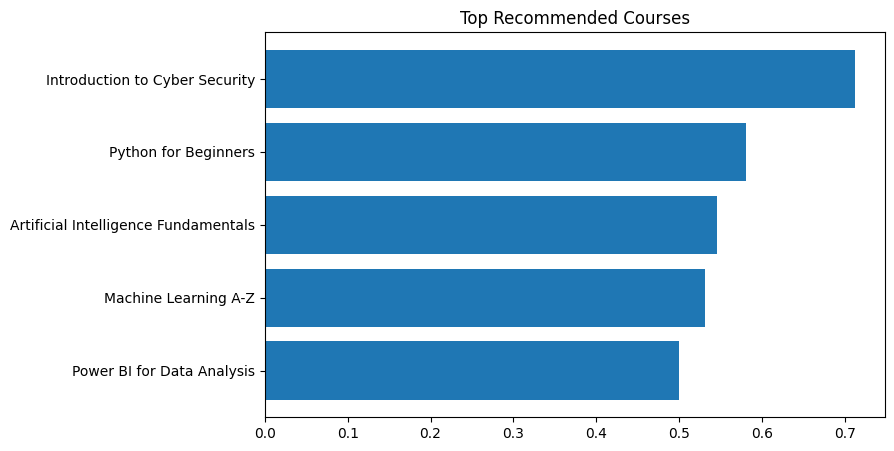

In [9]:
top = hybrid_recommend(1)

plt.figure(figsize=(8,5))
plt.barh(top['title'], top['score'])
plt.title("Top Recommended Courses")
plt.gca().invert_yaxis()
plt.show()

In [10]:
def precision_at_k(user_id, recommended, interactions_df, k=5):

    # الكورسات اللي المستخدم حبها فعلاً
    actual_liked = interactions_df[
        (interactions_df['user_id'] == user_id) &
        (interactions_df['rating'] >= 3)
    ]['content_id'].tolist()

    if len(actual_liked) == 0:
        return 0

    recommended_k = recommended[:k]

    relevant = len(set(recommended_k) & set(actual_liked))

    return relevant / k

In [11]:
user_id = 1

recs = hybrid_recommend(user_id)['content_id'].tolist()

precision = precision_at_k(user_id, recs, interactions_df, k=5)

print("Precision@5:", precision)

Precision@5: 0.6


In [12]:
def precision_at_k(user_id, k=5):

    recs = hybrid_recommend(user_id)['content_id'].tolist()

    actual = interactions_df[
        (interactions_df['user_id'] == user_id) &
        (interactions_df['rating'] >= 3)
    ]['content_id'].tolist()

    if len(actual) == 0:
        return None

    return len(set(recs[:k]) & set(actual)) / k

In [13]:
users = interactions_df['user_id'].unique()

precisions = []

for u in users:
    try:
        p = precision_at_k(u, k=5)

        if p is not None:
            precisions.append(p)

    except:
        continue

print("📊 Average Precision@5:", sum(precisions)/len(precisions))

📊 Average Precision@5: 0.5081721771678035


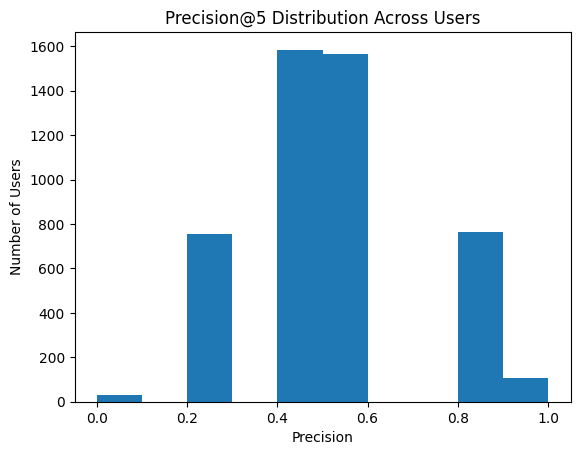

In [14]:
import matplotlib.pyplot as plt

plt.hist(precisions, bins=10)
plt.title("Precision@5 Distribution Across Users")
plt.xlabel("Precision")
plt.ylabel("Number of Users")
plt.show()